## Import Python Packages

In [1]:
#Importing packages
import pandas as pd
import requests
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from dotenv import dotenv_values

pd.set_option('display.max_columns', None) # show all columns
warnings.filterwarnings("ignore") # suppress warnings

### 1.2 Save your API key as a variable:
The getpass() function is used to prompt users to enter a password or other sensitive information (such as your API key) without showing the characters on the screen. We will save your API key as a variable so we can use it later in our code without needing to write it every time.

In [2]:
config = dotenv_values(".env")  
census_api_key = config['API_KEY']

print(census_api_key)

20d9d0785cd62d39740defbf219a0b99825175fe



Some links to explore what is available:

*   Census ACS Data 5-Year Estimate: https://www.census.gov/programs-surveys/acs/data/data-via-api.html
*   List item: Example URLs to use when querying Census data:
https://api.census.gov/data/2023/acs/acs5/examples.html






In [3]:
#Saving Census input info as variables

census_code = 'B19013_001E' # 'Median Household Income', you can search a different available table as well
year = '2023' # The latest year the ACS has data for
state = '04' # State code for Arizona
county_code = '013' # The "*" here is a wildcard, meaning that it will query all of the available counties in the State

#Note: We will use the "*" for the county code for now, to get the info for all the counties in AZ,
# we will use the county code for Maricopa later on to filter the data.
# county_code = '013' #County code for Maricopa County

### 1.2.1 Query the data from the Census API

As you can see in the output, our data is divided by **Census Tracks**. These "tracks" are the geographical divisions used by the Census to collect data.

In [4]:
### get census data
def fetchCensusData(census_code, year, state, county_code):
  census_url = f'https://api.census.gov/data/{year}/acs/acs5?get=NAME,{census_code}&for=tract:*&in=state:{state}&in=county:{county_code}&key={census_api_key}'
  response = requests.get(census_url)
  data = response.json()
  df_census = pd.DataFrame(data[1:], columns=data[0])
  return df_census

### Total PopulationL Occupied v.s. rent

In [5]:
### Total Population in Occupied Housing Units by Tenure

codes_25008 = ['B25008_001E','B25008_002E','B25008_003E']

df_B25008 = fetchCensusData(",".join(codes_25008), year, state, county_code)

df_B25008[codes_25008] = df_B25008[codes_25008].astype(int)
df_B25008['OwnerOccupied'] = df_B25008['B25008_002E'] / df_B25008['B25008_001E']

df_B25008['RenterOccupied'] = df_B25008['B25008_003E'] / df_B25008['B25008_001E']

codes_25008.append('NAME')
df_B25008.drop(columns=codes_25008, inplace=True)

df_B25008['LiveType'] = df_B25008[['OwnerOccupied', 'RenterOccupied']].idxmax(axis=1)

df_B25008['GeoID'] = df_B25008['state'] + df_B25008['county'] + df_B25008['tract']
df_B25008.head()

,state,county,tract,OwnerOccupied,RenterOccupied,LiveType,GeoID
0,04,013,010102,0.921170,0.078830,OwnerOccupied,04013010102
1,04,013,010103,0.969030,0.030970,OwnerOccupied,04013010103
2,04,013,010104,0.968061,0.031939,OwnerOccupied,04013010104
3,04,013,030401,0.930886,0.069114,OwnerOccupied,04013030401
4,04,013,030402,0.904647,0.095353,OwnerOccupied,04013030402


### Gross Rent Percentage

In [6]:
### Gross Rent as a Percentage of Household Income in the Past 12 Months

codes_25070 = ['B25070_001E','B25070_002E','B25070_003E','B25070_004E','B25070_005E','B25070_006E','B25070_007E','B25070_008E','B25070_009E','B25070_010E']

df_B25070 = fetchCensusData(",".join(codes_25070),year,state,county_code)
df_B25070[codes_25070] = df_B25070[codes_25070].astype(int)
df_B25070 = df_B25070.loc[df_B25070['B25070_001E'] > 0,:]
df_B25070['lowBurdan'] = (df_B25070['B25070_002E'] + df_B25070['B25070_003E']) / df_B25070['B25070_001E']
df_B25070['moderateBurdan'] = (df_B25070['B25070_004E'] + df_B25070['B25070_005E']) / df_B25070['B25070_001E']
df_B25070['costBurdan']=  (df_B25070['B25070_007E']+ df_B25070['B25070_006E'] + df_B25070['B25070_008E'] + df_B25070['B25070_009E']) / df_B25070['B25070_001E']
df_B25070['highBurdan'] = df_B25070['B25070_010E'] / df_B25070['B25070_001E']

codes_25070.append('NAME')

df_B25070.drop(columns=codes_25070, inplace=True)
df_B25070['burden'] = df_B25070[['lowBurdan', 'moderateBurdan', 'costBurdan', 'highBurdan']].idxmax(axis=1)
df_B25070['GeoID'] = df_B25070['state'] + df_B25070['county'] + df_B25070['tract']

df_B25070.head()

,state,county,tract,lowBurdan,moderateBurdan,costBurdan,highBurdan,burden,GeoID
0,04,013,010102,0.763441,0.000,0.000000,0.000000,lowBurdan,04013010102
1,04,013,010103,0.815385,0.000,0.000000,0.000000,lowBurdan,04013010103
2,04,013,010104,0.000000,0.000,0.196429,0.000000,costBurdan,04013010104
3,04,013,030401,0.188119,0.000,0.217822,0.321782,highBurdan,04013030401
4,04,013,030402,0.072000,0.472,0.336000,0.056000,moderateBurdan,04013030402


### Race demographic data

In [7]:
### Race demographic data
# dictionary: https://api.census.gov/data/2023/acs/acs1/variables.html

codes_race = ['B02001_001E','B02001_002E','B02001_003E','B03001_003E','B02001_004E','B02001_005E','B02001_006E','B02001_007E','B02001_009E']
df_race = fetchCensusData(','.join(codes_race),year,state,county_code)

for n in codes_race:
  df_race[n] = df_race[n].astype(float)
  if n != 'B02001_001E':
    df_race[n] = df_race[n] / df_race['B02001_001E']

df_race.rename(columns={"B02001_001E": "Total", "B02001_002E": "White Alone", "B02001_003E": "Black Alone",'B03001_003E': "Hispanic or Latino",
                        "B02001_004E": "American Indian or Alaska Native Alone","B02001_005E": "Asian Alone",
                        "B02001_006E": "Native Hawaiian or Pacific Islander Alone","B02001_007E": "Some other race",
                        "B02001_009E": "Mixed race (exluding \"Some other race\")"},
                         inplace=True, errors = "raise")

races = ['White Alone','Black Alone','Hispanic or Latino','American Indian or Alaska Native Alone','Asian Alone',
                               'Native Hawaiian or Pacific Islander Alone','Some other race','Mixed race (exluding \"Some other race\")']
df_race['Majority'] = df_race[races].idxmax(axis=1)
df_race['GeoID'] = df_race['state'] + df_race['county'] + df_race['tract']
df_race.drop(columns=['NAME','Total'], inplace=True)

df_race.head()

,White Alone,Black Alone,Hispanic or Latino,American Indian or Alaska Native Alone,Asian Alone,Native Hawaiian or Pacific Islander Alone,Some other race,"Mixed race (exluding ""Some other race"")",state,county,tract,Majority,GeoID
0,0.916840,0.005427,0.085874,0.000000,0.012291,0.0,0.002235,0.020910,04,013,010102,White Alone,04013010102
1,0.918229,0.003803,0.076881,0.000000,0.000000,0.0,0.004890,0.057865,04,013,010103,White Alone,04013010103
2,0.955605,0.000000,0.010220,0.000000,0.007027,0.0,0.000000,0.025232,04,013,010104,White Alone,04013010104
3,0.912521,0.005691,0.017707,0.000000,0.025295,0.0,0.000000,0.043634,04,013,030401,White Alone,04013030401
4,0.927281,0.000000,0.014929,0.004816,0.016855,0.0,0.008909,0.006742,04,013,030402,White Alone,04013030402


### Tenure by Unit in Structure:

In [8]:

# categorize the house size
def categorize_data(df):
    categories = {
        "Single-family homes": ["B25032_003E", "B25032_004E"],
        "Small multi-unit buildings (2-4 units)": ["B25032_005E", "B25032_006E"],
        "Larger apartment complexes (5+ units)": ["B25032_007E", "B25032_008E", "B25032_009E", "B25032_010E"],
        "Mobile homes, boats, RVs, etc.": ["B25032_011E", "B25032_012E"],
    }

    result = {}
    for category, cols in categories.items():
        df[cols] = df[cols].astype(int)
        result[category] = df[cols].sum(axis=1)

    df_result = pd.DataFrame(result)

    # Totals
    df_result["total_units"] = df["B25032_001E"].astype(int)

    # calculate Ratios
    for category in categories.keys():
        df_result[category] = df_result[category] / df_result["total_units"]

    ## categorize the major houseType
    df_result['majorHouseType'] = df_result[['Single-family homes', 'Small multi-unit buildings (2-4 units)', 'Larger apartment complexes (5+ units)']].idxmax(axis=1)
    # contain tract, county, state
    df_result["tract"] = df["tract"]
    df_result["county"] = df["county"]
    df_result["state"] = df["state"]

    df_result = df_result.loc[df_result["total_units"] > 0,:]
    #
    df_result.drop(columns=["total_units"], inplace=True)

    return df_result

df_B25032 = fetchCensusData("B25032_001E,B25032_003E,B25032_004E,B25032_005E,B25032_006E,B25032_007E,B25032_008E,B25032_009E,B25032_010E,B25032_011E,B25032_012E", year, state, county_code)

df_B25032Sort = categorize_data(df_B25032)

df_B25032Sort['GeoID'] = df_B25032Sort['state'] + df_B25032Sort['county'] + df_B25032Sort['tract']

df_B25032Sort.head()


,Single-family homes,Small multi-unit buildings (2-4 units),Larger apartment complexes (5+ units),"Mobile homes, boats, RVs, etc.",majorHouseType,tract,county,state,GeoID
0,0.967068,0.000000,0.000000,0.000000,Single-family homes,010102,013,04,04013010102
1,0.890501,0.000000,0.017150,0.049472,Single-family homes,010103,013,04,04013010103
2,0.967761,0.000000,0.000000,0.000000,Single-family homes,010104,013,04,04013010104
3,0.904664,0.000000,0.011969,0.000000,Single-family homes,030401,013,04,04013030401
4,0.837656,0.029046,0.000000,0.068465,Single-family homes,030402,013,04,04013030402


### Median income

In [9]:
median_df = fetchCensusData("B19013_001E", year=year, state=state, county_code=county_code)

median_df['B19013_001E'] = median_df['B19013_001E'].astype(int)

median_df.rename(columns={'B19013_001E': 'medianIncome'}, inplace=True)

median_df.drop(columns='NAME', inplace=True)
median_df['incomeLevel'] = pd.qcut(median_df['medianIncome'], q=4, labels=['Low', 'Moderate', 'High', 'Very High'])

median_df['GeoID'] = median_df['state'] + median_df['county'] + median_df['tract']

median_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   medianIncome  1009 non-null   int64   
 1   state         1009 non-null   object  
 2   county        1009 non-null   object  
 3   tract         1009 non-null   object  
 4   incomeLevel   1009 non-null   category
 5   GeoID         1009 non-null   object  
dtypes: category(1), int64(1), object(4)
memory usage: 40.7+ KB


### 1.2.2 Data Quality check with plots:


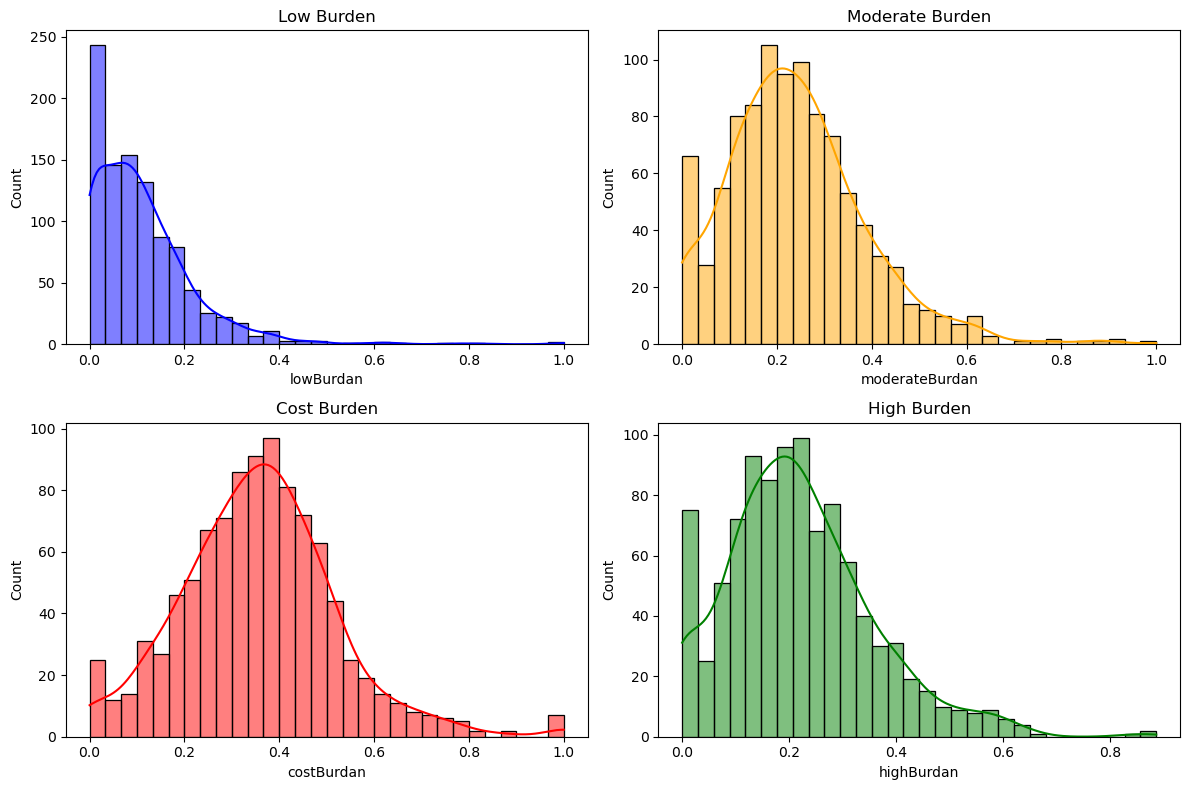

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df_B25070['lowBurdan'], bins=30, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Low Burden')

sns.histplot(df_B25070['moderateBurdan'], bins=30, kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Moderate Burden')

sns.histplot(df_B25070['costBurdan'], bins=30, kde=True, ax=axes[1, 0], color='red')
axes[1, 0].set_title('Cost Burden')

sns.histplot(df_B25070['highBurdan'], bins=30, kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('High Burden')

plt.tight_layout()
plt.show()

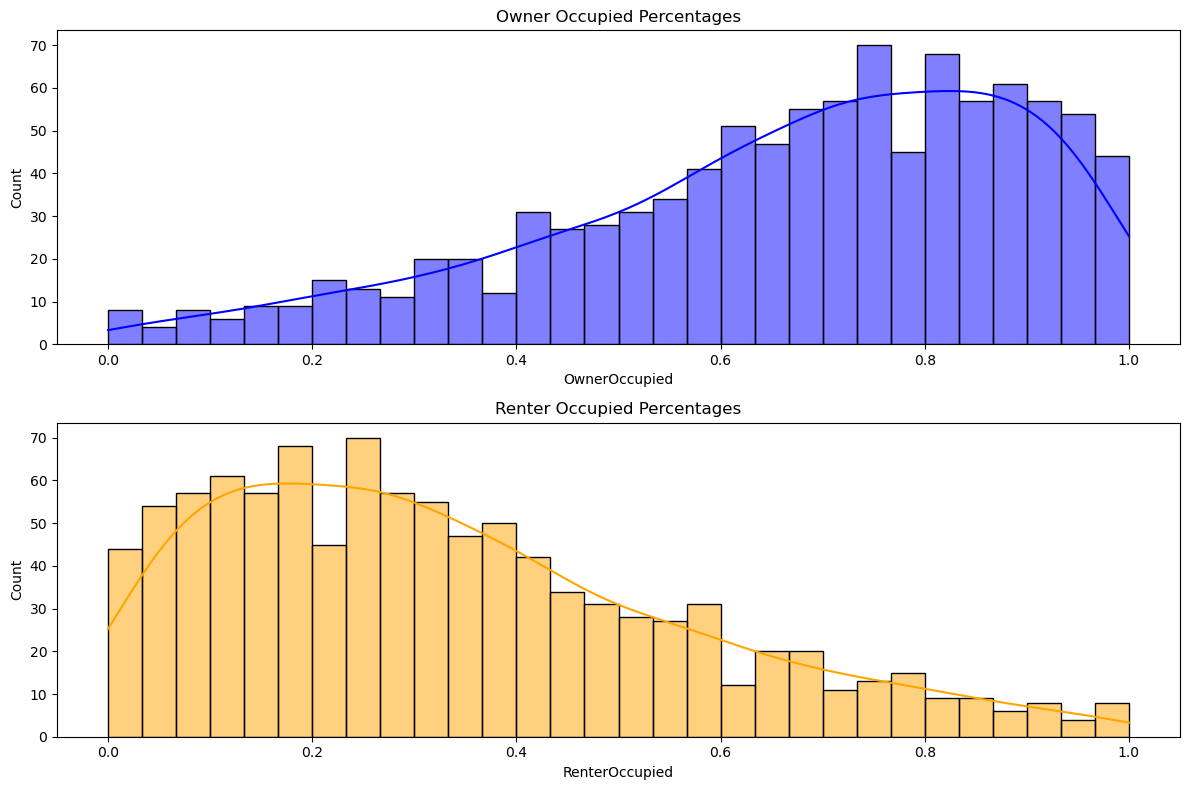

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.histplot(df_B25008['OwnerOccupied'], bins=30, kde=True, ax=axes[0], color='blue' )
axes[0].set_title('Owner Occupied Percentages')

sns.histplot(df_B25008['RenterOccupied'], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Renter Occupied Percentages')

plt.tight_layout()
plt.show()

<Axes: xlabel='medianIncome', ylabel='Count'>

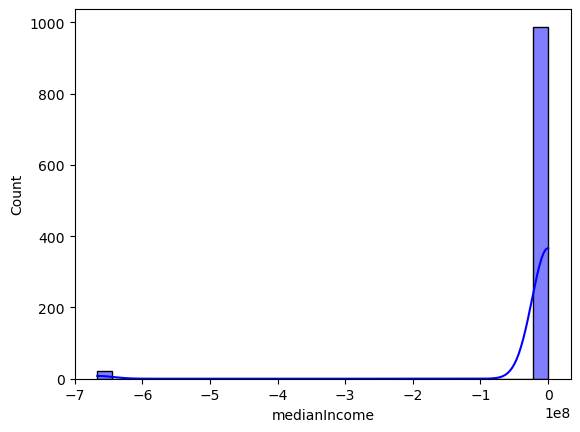

In [12]:
sns.histplot(median_df['medianIncome'],bins=30, kde=True, color='blue')

**Median Income** has the values less than zero, we need to filter out these invalid numbers.

<Axes: xlabel='medianIncome', ylabel='Count'>

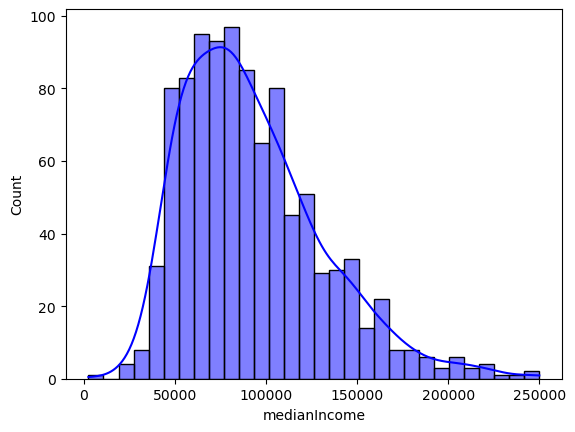

In [13]:
median_df_new  = median_df.loc[median_df['medianIncome'] >= 0, :]

sns.histplot(median_df_new['medianIncome'],bins=30, kde=True, color='blue')

### Get 2024 eviction data:

In [14]:
from io import BytesIO

url = 'https://raw.githubusercontent.com/UnitForDataScience/Projects-Spring-2025/refs/heads/main/Displaced%20Voices/Data/data_geocoded.csv'

response = requests.get(url, stream=True)
response.raise_for_status()  # 若連線失敗會報錯
csv_file = BytesIO(response.content)

eviction2024 = pd.read_csv(csv_file)

eviction2024.head()

,date,year,month,street_address_1,city,state,county,zip_code,type,street_address_1_clean,zip_code_clean,geocoded_address,is_match,is_exact,returned_address,coordinates,tiger_line,side,state_fips,county_fips,tract,block,long,lat,geoid,data_type
0,2024-01-02,2024,2024-01,4404 W CHARTER OAK ROAD,GLENDALE,Arizona,Maricopa,85304,eviction_filing,4404 W CHARTER OAK RD,85304,"4404 W CHARTER OAK RD, GLENDALE, Arizona, 85304",Match,Exact,"4404 W CHARTER OAK RD, GLENDALE, AZ, 85304","-112.154995297645,33.597802814472",128177101.0,R,4.0,13.0,104219.0,1021.0,-112.154995,33.597803,4.013104e+09,eviction_filing
1,2024-01-02,2024,2024-01,7111 NORTH 75TH AVE APT 2043,GLENDALE,Arizona,Maricopa,85303,eviction_filing,7111 N 75TH AVE,85303,"7111 N 75TH AVE, GLENDALE, Arizona, 85303",Match,Exact,"7111 N 75TH AVE, GLENDALE, AZ, 85303","-112.220374489876,33.540036954393",128916826.0,R,4.0,13.0,92705.0,1024.0,-112.220374,33.540037,4.013093e+09,eviction_filing
2,2024-01-02,2024,2024-01,3228 W Missouri Ave,Phoenix,Arizona,Maricopa,85017,eviction_filing,3228 W MISSOURI AVE,85017,"3228 W MISSOURI AVE, Phoenix, Arizona, 85017",Match,Exact,"3228 W MISSOURI AVE, PHOENIX, AZ, 85017","-112.128648457377,33.516781172177",653211044.0,R,4.0,13.0,107202.0,1022.0,-112.128648,33.516781,4.013107e+09,eviction_filing
3,2024-01-02,2024,2024-01,4045 WEST BELL ROAD,Phoenix,Arizona,Maricopa,85053,eviction_filing,4045 W BELL RD,85053,"4045 W BELL RD, Phoenix, Arizona, 85053",Match,Exact,"4045 W BELL RD, PHOENIX, AZ, 85053","-112.145521353769,33.639356291529",128314536.0,L,4.0,13.0,104226.0,1000.0,-112.145521,33.639356,4.013104e+09,eviction_filing
4,2024-01-02,2024,2024-01,1311 WEST BASELINE ROAD APT 2018,Tempe,Arizona,Maricopa,85283,eviction_filing,1311 W BASELINE RD,85283,"1311 W BASELINE RD, Tempe, Arizona, 85283",Match,Exact,"1311 W BASELINE RD, TEMPE, AZ, 85283","-111.958388270239,33.378192590822",243919395.0,L,4.0,13.0,320007.0,3002.0,-111.958388,33.378193,4.013320e+09,eviction_filing


In [15]:
# Remove rows with missing 'geoid' values
eviction2024.dropna(subset=['geoid'], inplace=True)

# Check for missing values again
missing_values = eviction2024.isnull().sum()
print(missing_values)

# Alternatively, get a summary of missing values
missing_values_summary = eviction2024.isnull().sum().sum()
print(f"Total missing values: {missing_values_summary}")

print(eviction2024.shape)


date                      0
year                      0
month                     0
street_address_1          0
city                      0
state                     0
county                    0
zip_code                  0
type                      0
street_address_1_clean    0
zip_code_clean            0
geocoded_address          0
is_match                  0
is_exact                  0
returned_address          0
coordinates               0
tiger_line                0
side                      0
state_fips                0
county_fips               0
tract                     0
block                     0
long                      0
lat                       0
geoid                     0
data_type                 0
dtype: int64
Total missing values: 0
(52900, 26)


In [16]:
eviction2024 = eviction2024.loc[:,['geoid', 'zip_code', 'type']]

eviction2024['zip_code'] = eviction2024['zip_code'].astype(str)

eviction2024['GeoID'] = eviction2024['geoid'].astype(int).astype(str).str.zfill(11)
eviction2024.head()

,geoid,zip_code,type,GeoID
0,4.013104e+09,85304,eviction_filing,04013104219
1,4.013093e+09,85303,eviction_filing,04013092705
2,4.013107e+09,85017,eviction_filing,04013107202
3,4.013104e+09,85053,eviction_filing,04013104226
4,4.013320e+09,85283,eviction_filing,04013320007


In [17]:
eviction_count = eviction2024.groupby(['GeoID', 'zip_code'])['type'].count().reset_index()

eviction_count.rename(columns={'type': 'filedEviction'}, inplace=True)

eviction_count.head(40)

,GeoID,zip_code,filedEviction
0,04013010102,85331,1
1,04013010103,85262,1
2,04013030401,85331,1
3,04013030401,85377,1
4,04013030402,85331,12
5,04013040502,85390,29
6,04013040506,85375,2
7,04013040507,85375,3
8,04013040514,85375,3
9,04013040515,85320,1


In [18]:
column_sum = eviction_count['filedEviction'].sum()
print(column_sum)

52900


## Merging the Tables

In our case, the dataframes share common variables such as **state**, **county**, **tract**, and GeoID.

GeoID is a concatenation of **state**, **county**, and **tract**, forming an 11-digit identifier.

**P.S. A tract is a precise geographic identifier that is updated every five years.**

In [19]:
df_economic = median_df_new.merge(df_B25032Sort.drop(columns=['state', 'county', 'tract']), how='inner', on='GeoID').\
merge(df_B25070.drop(columns=['state', 'county', 'tract']), how='inner', on='GeoID').\
merge(df_B25008.drop(columns=['state', 'county', 'tract']), how='inner', on='GeoID').\
merge(df_race.drop(columns=['state', 'county', 'tract']),how='inner', on='GeoID')

df_economic.head()

,medianIncome,state,county,tract,incomeLevel,GeoID,Single-family homes,Small multi-unit buildings (2-4 units),Larger apartment complexes (5+ units),"Mobile homes, boats, RVs, etc.",majorHouseType,lowBurdan,moderateBurdan,costBurdan,highBurdan,burden,OwnerOccupied,RenterOccupied,LiveType,White Alone,Black Alone,Hispanic or Latino,American Indian or Alaska Native Alone,Asian Alone,Native Hawaiian or Pacific Islander Alone,Some other race,"Mixed race (exluding ""Some other race"")",Majority
0,188486,04,013,010102,Very High,04013010102,0.967068,0.000000,0.000000,0.000000,Single-family homes,0.763441,0.000,0.000000,0.000000,lowBurdan,0.921170,0.078830,OwnerOccupied,0.916840,0.005427,0.085874,0.000000,0.012291,0.0,0.002235,0.020910,White Alone
1,117813,04,013,010103,Very High,04013010103,0.890501,0.000000,0.017150,0.049472,Single-family homes,0.815385,0.000,0.000000,0.000000,lowBurdan,0.969030,0.030970,OwnerOccupied,0.918229,0.003803,0.076881,0.000000,0.000000,0.0,0.004890,0.057865,White Alone
2,140587,04,013,010104,Very High,04013010104,0.967761,0.000000,0.000000,0.000000,Single-family homes,0.000000,0.000,0.196429,0.000000,costBurdan,0.968061,0.031939,OwnerOccupied,0.955605,0.000000,0.010220,0.000000,0.007027,0.0,0.000000,0.025232,White Alone
3,145865,04,013,030401,Very High,04013030401,0.904664,0.000000,0.011969,0.000000,Single-family homes,0.188119,0.000,0.217822,0.321782,highBurdan,0.930886,0.069114,OwnerOccupied,0.912521,0.005691,0.017707,0.000000,0.025295,0.0,0.000000,0.043634,White Alone
4,108031,04,013,030402,High,04013030402,0.837656,0.029046,0.000000,0.068465,Single-family homes,0.072000,0.472,0.336000,0.056000,moderateBurdan,0.904647,0.095353,OwnerOccupied,0.927281,0.000000,0.014929,0.004816,0.016855,0.0,0.008909,0.006742,White Alone


In [20]:
df_economic.shape, eviction_count.shape

((984, 28), (1487, 3))

## Merge demographic data with eviction record in 2024



In [21]:
fullDataset = eviction_count.merge(df_economic, how='right', on='GeoID')
fullDataset

,GeoID,zip_code,filedEviction,medianIncome,state,county,tract,incomeLevel,Single-family homes,Small multi-unit buildings (2-4 units),Larger apartment complexes (5+ units),"Mobile homes, boats, RVs, etc.",majorHouseType,lowBurdan,moderateBurdan,costBurdan,highBurdan,burden,OwnerOccupied,RenterOccupied,LiveType,White Alone,Black Alone,Hispanic or Latino,American Indian or Alaska Native Alone,Asian Alone,Native Hawaiian or Pacific Islander Alone,Some other race,"Mixed race (exluding ""Some other race"")",Majority
0,04013010102,85331,1.0,188486,04,013,010102,Very High,0.967068,0.000000,0.000000,0.000000,Single-family homes,0.763441,0.000000,0.000000,0.000000,lowBurdan,0.921170,0.078830,OwnerOccupied,0.916840,0.005427,0.085874,0.000000,0.012291,0.0,0.002235,0.020910,White Alone
1,04013010103,85262,1.0,117813,04,013,010103,Very High,0.890501,0.000000,0.017150,0.049472,Single-family homes,0.815385,0.000000,0.000000,0.000000,lowBurdan,0.969030,0.030970,OwnerOccupied,0.918229,0.003803,0.076881,0.000000,0.000000,0.0,0.004890,0.057865,White Alone
2,04013010104,NaN,NaN,140587,04,013,010104,Very High,0.967761,0.000000,0.000000,0.000000,Single-family homes,0.000000,0.000000,0.196429,0.000000,costBurdan,0.968061,0.031939,OwnerOccupied,0.955605,0.000000,0.010220,0.000000,0.007027,0.0,0.000000,0.025232,White Alone
3,04013030401,85331,1.0,145865,04,013,030401,Very High,0.904664,0.000000,0.011969,0.000000,Single-family homes,0.188119,0.000000,0.217822,0.321782,highBurdan,0.930886,0.069114,OwnerOccupied,0.912521,0.005691,0.017707,0.000000,0.025295,0.0,0.000000,0.043634,White Alone
4,04013030401,85377,1.0,145865,04,013,030401,Very High,0.904664,0.000000,0.011969,0.000000,Single-family homes,0.188119,0.000000,0.217822,0.321782,highBurdan,0.930886,0.069114,OwnerOccupied,0.912521,0.005691,0.017707,0.000000,0.025295,0.0,0.000000,0.043634,White Alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1528,04013817500,NaN,NaN,64926,04,013,817500,Moderate,0.801780,0.000000,0.000000,0.013650,Single-family homes,0.028939,0.173633,0.254019,0.456592,highBurdan,0.859898,0.140102,OwnerOccupied,0.936681,0.005095,0.052038,0.003639,0.006186,0.0,0.002183,0.021470,White Alone
1529,04013817600,85212,1.0,138208,04,013,817600,Very High,0.861401,0.006194,0.000000,0.031746,Single-family homes,0.153846,0.292308,0.123077,0.273077,moderateBurdan,0.914421,0.085579,OwnerOccupied,0.716588,0.026947,0.150169,0.024103,0.048883,0.0,0.058226,0.056601,White Alone
1530,04013941000,NaN,NaN,49926,04,013,941000,Low,0.654676,0.000000,0.000000,0.038849,Single-family homes,0.164319,0.093897,0.107981,0.070423,lowBurdan,0.650252,0.349748,OwnerOccupied,0.030410,0.003543,0.118984,0.807204,0.023324,0.0,0.027753,0.040449,American Indian or Alaska Native Alone
1531,04013941200,NaN,NaN,58229,04,013,941200,Low,0.797048,0.000000,0.000000,0.095941,Single-family homes,0.172414,0.137931,0.137931,0.137931,lowBurdan,0.926966,0.073034,OwnerOccupied,0.113296,0.002809,0.248127,0.738764,0.016854,0.0,0.026217,0.014045,American Indian or Alaska Native Alone


In [22]:
fullDataset.shape

(1533, 30)

In [23]:
column_sum = fullDataset['filedEviction'].sum()
print(column_sum)

52877.0


In [24]:
fullDataset.isnull().sum()

GeoID                                         0
zip_code                                     54
filedEviction                                54
medianIncome                                  0
state                                         0
county                                        0
tract                                         0
incomeLevel                                   0
Single-family homes                           0
Small multi-unit buildings (2-4 units)        0
Larger apartment complexes (5+ units)         0
Mobile homes, boats, RVs, etc.                0
majorHouseType                                0
lowBurdan                                     0
moderateBurdan                                0
costBurdan                                    0
highBurdan                                    0
burden                                        0
OwnerOccupied                                 0
RenterOccupied                                0
LiveType                                

In [25]:
fullDataset['filedEviction'] = fullDataset['filedEviction'].fillna(0).astype(int)

fullDataset['zip_code'] = fullDataset['zip_code'].fillna('N/A')

fullDataset.isnull().sum()

GeoID                                        0
zip_code                                     0
filedEviction                                0
medianIncome                                 0
state                                        0
county                                       0
tract                                        0
incomeLevel                                  0
Single-family homes                          0
Small multi-unit buildings (2-4 units)       0
Larger apartment complexes (5+ units)        0
Mobile homes, boats, RVs, etc.               0
majorHouseType                               0
lowBurdan                                    0
moderateBurdan                               0
costBurdan                                   0
highBurdan                                   0
burden                                       0
OwnerOccupied                                0
RenterOccupied                               0
LiveType                                     0
White Alone  

In [26]:
fullDataset.isnull().sum()

GeoID                                        0
zip_code                                     0
filedEviction                                0
medianIncome                                 0
state                                        0
county                                       0
tract                                        0
incomeLevel                                  0
Single-family homes                          0
Small multi-unit buildings (2-4 units)       0
Larger apartment complexes (5+ units)        0
Mobile homes, boats, RVs, etc.               0
majorHouseType                               0
lowBurdan                                    0
moderateBurdan                               0
costBurdan                                   0
highBurdan                                   0
burden                                       0
OwnerOccupied                                0
RenterOccupied                               0
LiveType                                     0
White Alone  

## Section 2: Clustering Analysis

In this analysis, we plan to use the k-means algorithm to identify distinct groups of tracts through clustering.

After performing the clustering analysis, we will conduct statistical tests such as a one-way ANOVA or trend tests to examine how factors like median income, burden of gross income, and the ratio of renters to owners vary across the clusters. Additionally, we will analyze the overall distribution of these variables.


### About K-means algorithms:

For the first thing, we need to find out the best parameter, how many clusters we will have in the datasets.

We will use the `scikit-learn` to find the best groups we will use.

In [27]:
fullDataCopy = fullDataset.copy()

df_Kmeans = fullDataCopy.drop(columns=['GeoID','state', 'county', 'tract','zip_code','LiveType', 'burden','majorHouseType','incomeLevel','Majority', 'filedEviction'])

df_Kmeans.head()

,medianIncome,Single-family homes,Small multi-unit buildings (2-4 units),Larger apartment complexes (5+ units),"Mobile homes, boats, RVs, etc.",lowBurdan,moderateBurdan,costBurdan,highBurdan,OwnerOccupied,RenterOccupied,White Alone,Black Alone,Hispanic or Latino,American Indian or Alaska Native Alone,Asian Alone,Native Hawaiian or Pacific Islander Alone,Some other race,"Mixed race (exluding ""Some other race"")"
0,188486,0.967068,0.0,0.000000,0.000000,0.763441,0.0,0.000000,0.000000,0.921170,0.078830,0.916840,0.005427,0.085874,0.0,0.012291,0.0,0.002235,0.020910
1,117813,0.890501,0.0,0.017150,0.049472,0.815385,0.0,0.000000,0.000000,0.969030,0.030970,0.918229,0.003803,0.076881,0.0,0.000000,0.0,0.004890,0.057865
2,140587,0.967761,0.0,0.000000,0.000000,0.000000,0.0,0.196429,0.000000,0.968061,0.031939,0.955605,0.000000,0.010220,0.0,0.007027,0.0,0.000000,0.025232
3,145865,0.904664,0.0,0.011969,0.000000,0.188119,0.0,0.217822,0.321782,0.930886,0.069114,0.912521,0.005691,0.017707,0.0,0.025295,0.0,0.000000,0.043634
4,145865,0.904664,0.0,0.011969,0.000000,0.188119,0.0,0.217822,0.321782,0.930886,0.069114,0.912521,0.005691,0.017707,0.0,0.025295,0.0,0.000000,0.043634


In [28]:
scaler = StandardScaler()

df_Kmeans['medianIncome'] = scaler.fit_transform(df_Kmeans[['medianIncome']])

df_Kmeans.head()

,medianIncome,Single-family homes,Small multi-unit buildings (2-4 units),Larger apartment complexes (5+ units),"Mobile homes, boats, RVs, etc.",lowBurdan,moderateBurdan,costBurdan,highBurdan,OwnerOccupied,RenterOccupied,White Alone,Black Alone,Hispanic or Latino,American Indian or Alaska Native Alone,Asian Alone,Native Hawaiian or Pacific Islander Alone,Some other race,"Mixed race (exluding ""Some other race"")"
0,2.881157,0.967068,0.0,0.000000,0.000000,0.763441,0.0,0.000000,0.000000,0.921170,0.078830,0.916840,0.005427,0.085874,0.0,0.012291,0.0,0.002235,0.020910
1,0.889811,0.890501,0.0,0.017150,0.049472,0.815385,0.0,0.000000,0.000000,0.969030,0.030970,0.918229,0.003803,0.076881,0.0,0.000000,0.0,0.004890,0.057865
2,1.531512,0.967761,0.0,0.000000,0.000000,0.000000,0.0,0.196429,0.000000,0.968061,0.031939,0.955605,0.000000,0.010220,0.0,0.007027,0.0,0.000000,0.025232
3,1.680229,0.904664,0.0,0.011969,0.000000,0.188119,0.0,0.217822,0.321782,0.930886,0.069114,0.912521,0.005691,0.017707,0.0,0.025295,0.0,0.000000,0.043634
4,1.680229,0.904664,0.0,0.011969,0.000000,0.188119,0.0,0.217822,0.321782,0.930886,0.069114,0.912521,0.005691,0.017707,0.0,0.025295,0.0,0.000000,0.043634


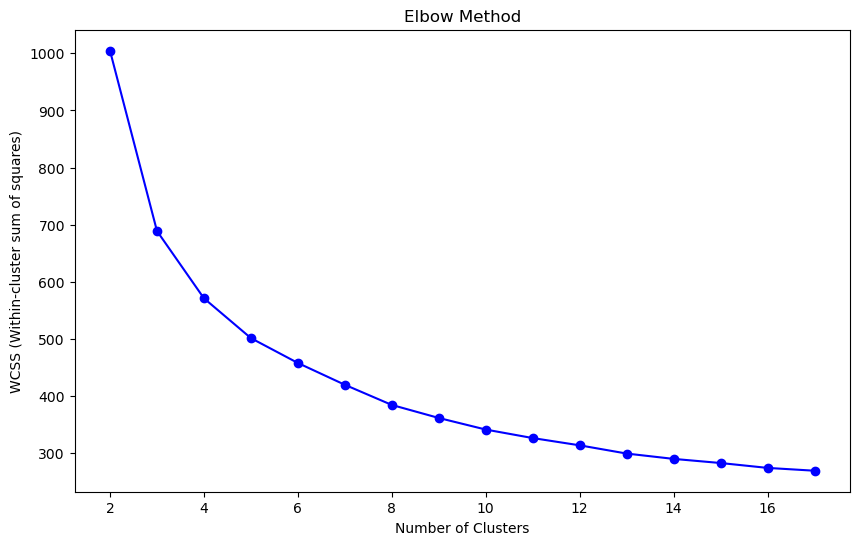

In [29]:
wcss = []
k_range = range(2, 18)
for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(df_Kmeans)
  wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-cluster sum of squares)')
plt.show()

In [30]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(df_Kmeans)
    score = silhouette_score(df_Kmeans, kmeans.labels_)
    print(f"Silhouette score for k={k}: {score}")

Silhouette score for k=2: 0.4453382561625397
Silhouette score for k=3: 0.35294296649810386
Silhouette score for k=4: 0.2747868553199738
Silhouette score for k=5: 0.25907278831439196
Silhouette score for k=6: 0.24320669868494035
Silhouette score for k=7: 0.23661650498941908
Silhouette score for k=8: 0.2118098651412616
Silhouette score for k=9: 0.21097692214826044


In [31]:
#Calinski-Harabasz Index
from sklearn.metrics import calinski_harabasz_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(df_Kmeans)
    score = calinski_harabasz_score(df_Kmeans, kmeans.labels_)
    print(f"CH Index for k={k}: {score}")

CH Index for k=2: 1683.9396937622196
CH Index for k=3: 1577.4391443473246
CH Index for k=4: 1369.0808963624734
CH Index for k=5: 1221.3815215054474
CH Index for k=6: 1086.4438122664083
CH Index for k=7: 1016.5574446419586
CH Index for k=8: 922.3213621038695
CH Index for k=9: 880.7899682521527


In [32]:
#Davies-Bouldin Index
from sklearn.metrics import davies_bouldin_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(df_Kmeans)
    score = davies_bouldin_score(df_Kmeans, kmeans.labels_)
    print(f"DB Index for k={k}: {score}")

DB Index for k=2: 0.8293612334631235
DB Index for k=3: 0.9413375943092902
DB Index for k=4: 1.1523683992863853
DB Index for k=5: 1.144046167809736
DB Index for k=6: 1.2815155679141998
DB Index for k=7: 1.2768186265661068
DB Index for k=8: 1.371219406790452
DB Index for k=9: 1.3268611364099223


In [33]:
optimizedK = 9
kmeansPred = KMeans(n_clusters=optimizedK, random_state=42, n_init=10)
kmeansPred.fit(df_Kmeans)
fullDataset['cluster'] = kmeansPred.labels_+1

fullDataset.head()

,GeoID,zip_code,filedEviction,medianIncome,state,county,tract,incomeLevel,Single-family homes,Small multi-unit buildings (2-4 units),Larger apartment complexes (5+ units),"Mobile homes, boats, RVs, etc.",majorHouseType,lowBurdan,moderateBurdan,costBurdan,highBurdan,burden,OwnerOccupied,RenterOccupied,LiveType,White Alone,Black Alone,Hispanic or Latino,American Indian or Alaska Native Alone,Asian Alone,Native Hawaiian or Pacific Islander Alone,Some other race,"Mixed race (exluding ""Some other race"")",Majority,cluster
0,04013010102,85331,1,188486,04,013,010102,Very High,0.967068,0.0,0.000000,0.000000,Single-family homes,0.763441,0.0,0.000000,0.000000,lowBurdan,0.921170,0.078830,OwnerOccupied,0.916840,0.005427,0.085874,0.0,0.012291,0.0,0.002235,0.020910,White Alone,4
1,04013010103,85262,1,117813,04,013,010103,Very High,0.890501,0.0,0.017150,0.049472,Single-family homes,0.815385,0.0,0.000000,0.000000,lowBurdan,0.969030,0.030970,OwnerOccupied,0.918229,0.003803,0.076881,0.0,0.000000,0.0,0.004890,0.057865,White Alone,1
2,04013010104,N/A,0,140587,04,013,010104,Very High,0.967761,0.0,0.000000,0.000000,Single-family homes,0.000000,0.0,0.196429,0.000000,costBurdan,0.968061,0.031939,OwnerOccupied,0.955605,0.000000,0.010220,0.0,0.007027,0.0,0.000000,0.025232,White Alone,7
3,04013030401,85331,1,145865,04,013,030401,Very High,0.904664,0.0,0.011969,0.000000,Single-family homes,0.188119,0.0,0.217822,0.321782,highBurdan,0.930886,0.069114,OwnerOccupied,0.912521,0.005691,0.017707,0.0,0.025295,0.0,0.000000,0.043634,White Alone,7
4,04013030401,85377,1,145865,04,013,030401,Very High,0.904664,0.0,0.011969,0.000000,Single-family homes,0.188119,0.0,0.217822,0.321782,highBurdan,0.930886,0.069114,OwnerOccupied,0.912521,0.005691,0.017707,0.0,0.025295,0.0,0.000000,0.043634,White Alone,7


<Axes: xlabel='cluster', ylabel='medianIncome'>

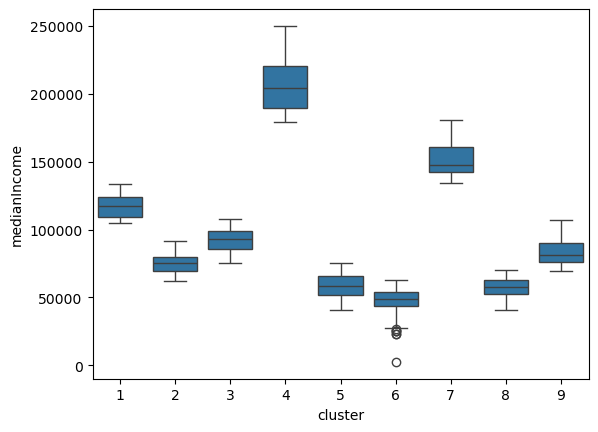

In [34]:
sns.boxplot(x='cluster', y='medianIncome', data=fullDataset)

<Axes: xlabel='cluster', ylabel='filedEviction'>

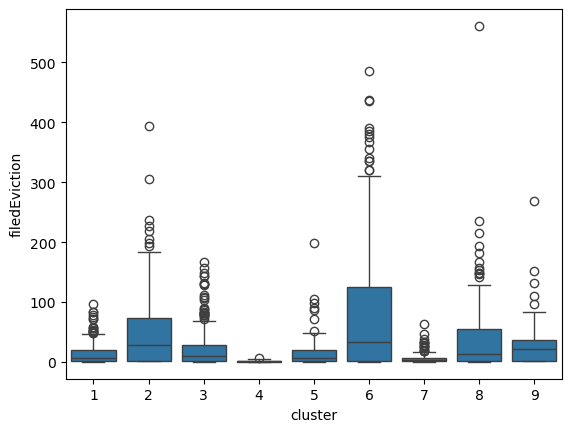

In [35]:
sns.boxplot(x='cluster', y='filedEviction', data=fullDataset)

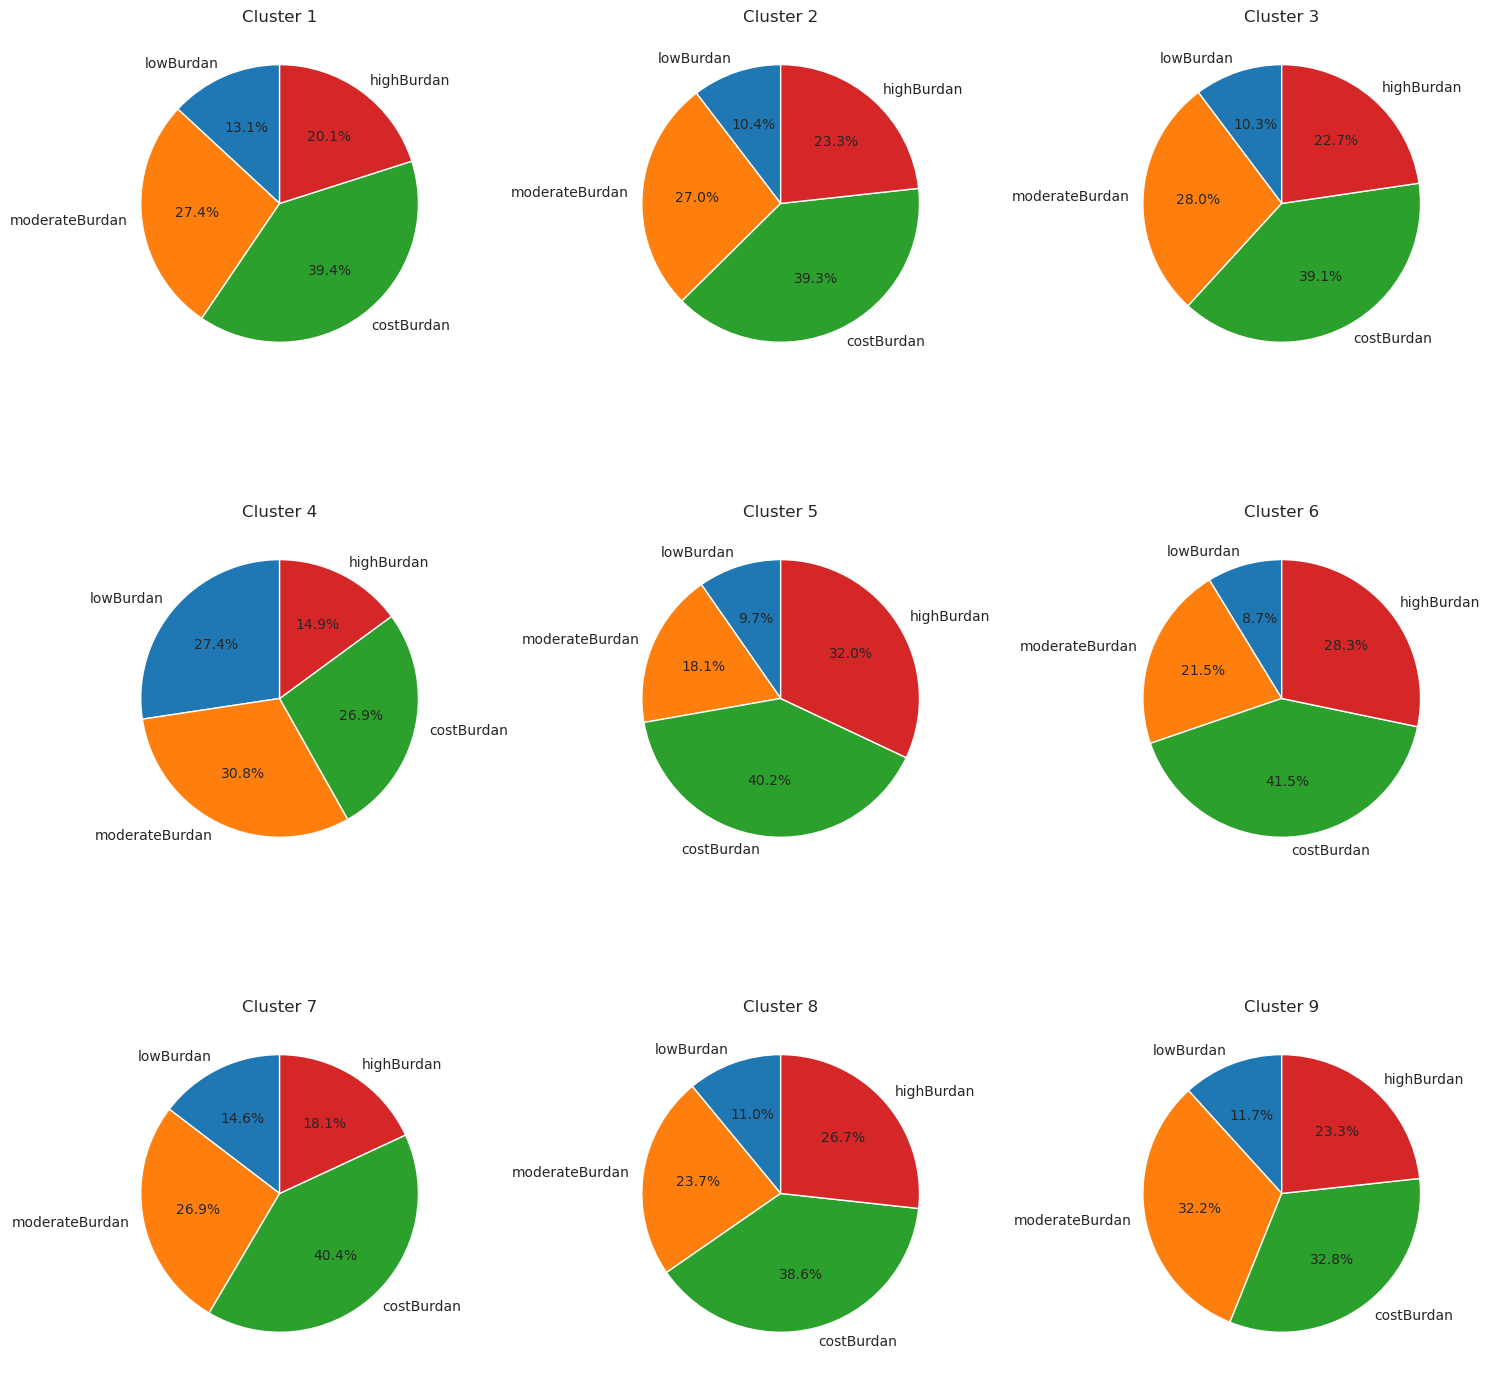

In [36]:
# Group by cluster and compute mean for each burden category
pie_data = fullDataset[['cluster', 'lowBurdan', 'moderateBurdan', 'costBurdan', 'highBurdan']] \
            .groupby('cluster').mean()

# Set up the plotting style
sns.set_style("whitegrid")

# Create 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()  # Flatten the 2D array for easy indexing

# Create one pie chart per cluster
for i, (cluster, row) in enumerate(pie_data.iterrows()):
    axes[i].pie(row, labels=row.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'Cluster {cluster}')

# Hide any unused subplots (in case there are fewer than 9)
for j in range(len(pie_data), 9):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

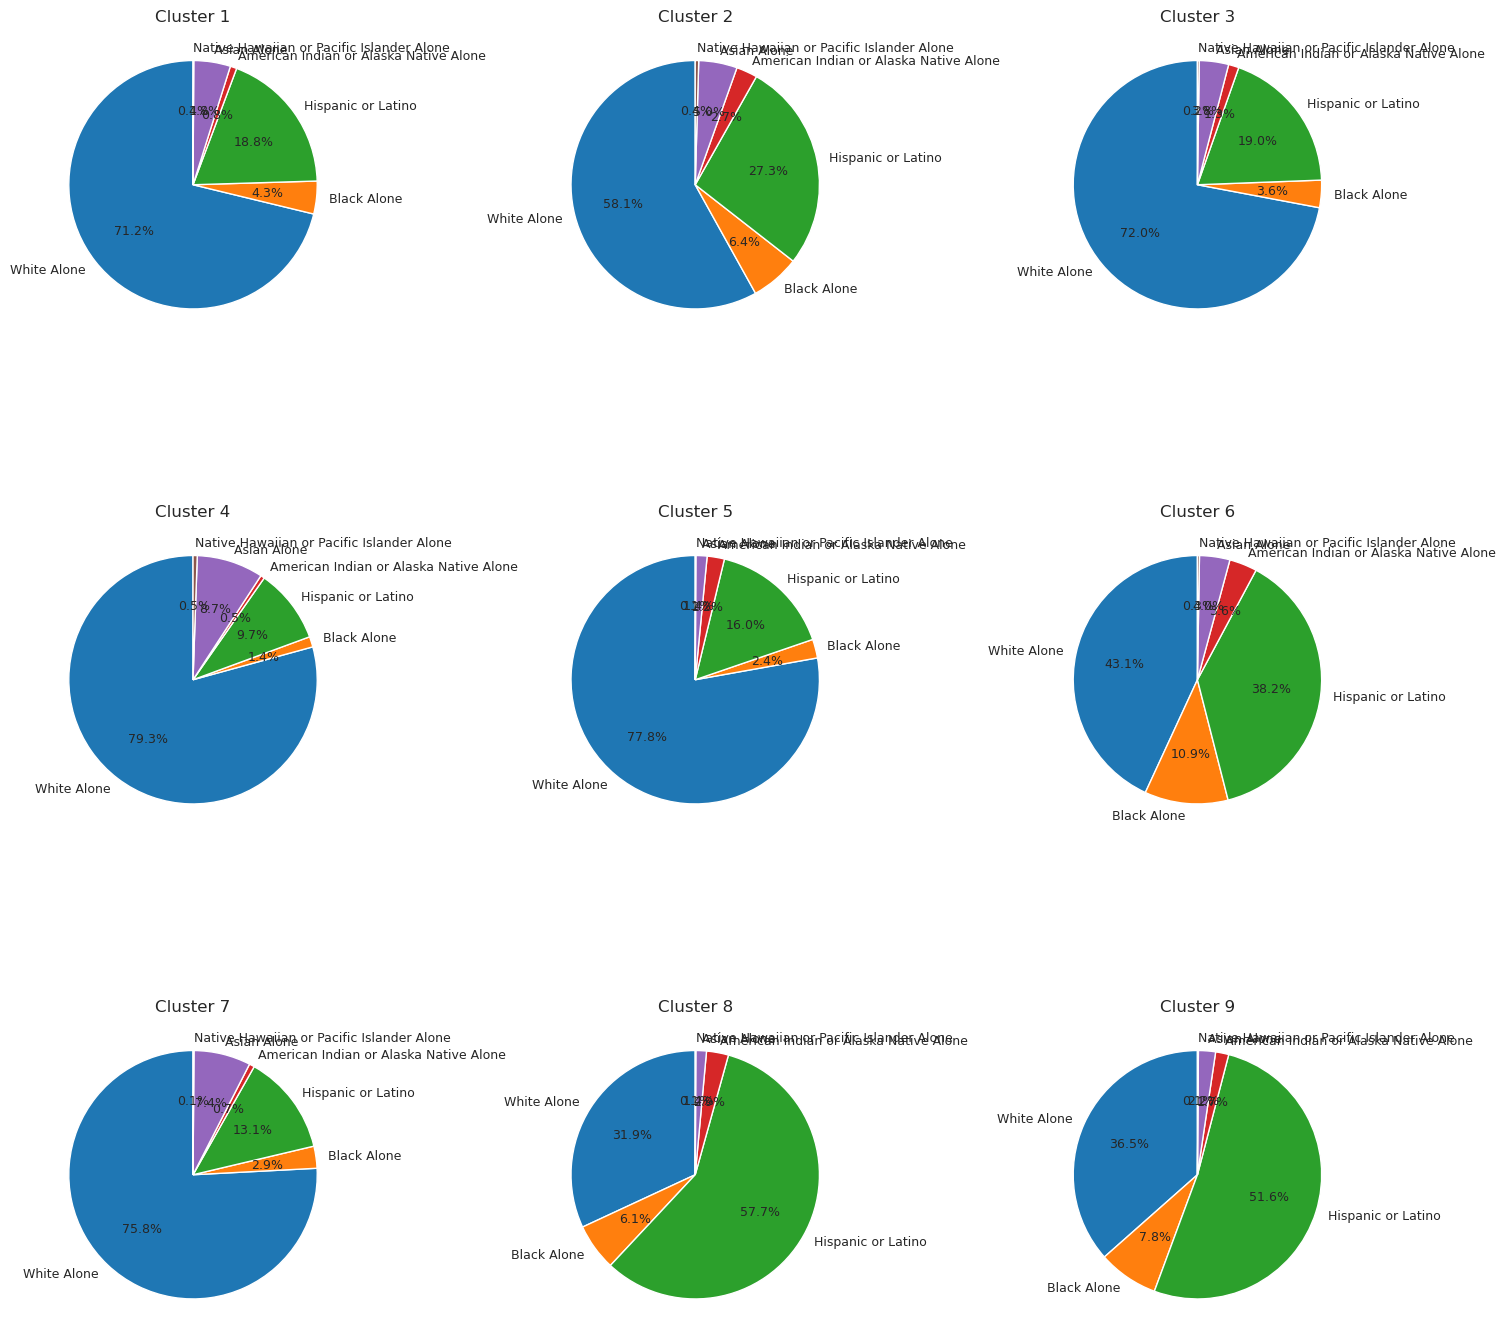

In [37]:
# Group by cluster and compute mean for each race category
race_pie_data = fullDataset[[
    'White Alone', 'Black Alone', 'Hispanic or Latino',
    'American Indian or Alaska Native Alone', 'Asian Alone',
    'Native Hawaiian or Pacific Islander Alone', 'cluster'
]].groupby('cluster').mean()

# Set up the plotting style
sns.set_style("whitegrid")

# Create 3x3 subplots for 9 clusters
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # Increased size
axes = axes.flatten()  # Flatten to 1D array

# Plot each cluster's pie chart
for i, (cluster, row) in enumerate(race_pie_data.iterrows()):
    axes[i].pie(
        row,
        labels=row.index,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 9}  # Reduce font size inside pies
    )
    axes[i].set_title(f'Cluster {cluster}', fontsize=12)  # Reduce title font size

# Hide any unused subplots
for j in range(len(race_pie_data), len(axes)):
    axes[j].axis('off')

# Add space between plots
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.tight_layout()
plt.show()

### One-Way ANOVA

In the following sections, we will use clustering to analyze how the clusters differ in demographic data.

$y_{ij} = μ + \beta_{i} + ϵ_{ij}$

where:
- $i$ denotes the i-th cluster,
- j denotes the j-th tract,
- $\beta_i$ represents the effect of the i-th cluster (i.e., the difference between clusters), and
- $ϵ_{ij}$ represents the residuals within clusters.


### Median income between clusters with filed eviction cases

In [38]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

import scipy.stats as stats

median_anova = smf.ols(formula='filedEviction ~ C(cluster) + medianIncome * C(incomeLevel)', data=fullDataset).fit()
anova_table = sm.stats.anova_lm(median_anova, typ=2)
print(anova_table)

                                   sum_sq      df          F        PR(>F)
C(cluster)                   4.010634e+05     8.0  15.833609  1.345259e-22
C(incomeLevel)               1.042465e+03     3.0   0.109748  9.544236e-01
medianIncome                 2.174328e+01     1.0   0.006867  9.339668e-01
medianIncome:C(incomeLevel)  6.300541e+03     3.0   0.663305  5.746373e-01
Residual                     4.803178e+06  1517.0        NaN           NaN


### LiveType between clusters with filed eviction cases

In [ ]:
eviction_anova = smf.ols(formula='filedEviction ~ C(cluster) + OwnerOccupied + RenterOccupied + C(LiveType):C(cluster)', data=fullDataset).fit()
anova_table = sm.stats.anova_lm(eviction_anova, typ=2)
print(anova_table)
print(eviction_anova.summary())

### Burden between clusters with filed eviction cases

In [40]:
burden_anova = smf.ols(formula='filedEviction ~ C(cluster) + lowBurdan + moderateBurdan + costBurdan + highBurdan + C(burden)+C(cluster):C(burden)', data=fullDataset).fit()
anova_table = sm.stats.anova_lm(burden_anova, typ=2)
print(anova_table)

                            sum_sq      df          F        PR(>F)
C(cluster)            7.099072e+05     8.0  28.029258  2.025284e-36
C(burden)             2.253363e+04     3.0   2.372520  9.359669e-02
C(cluster):C(burden)  3.094886e+04    24.0   0.407318  9.943975e-01
lowBurdan             1.199015e+04     1.0   3.787257  5.183151e-02
moderateBurdan        2.015293e+04     1.0   6.365585  1.173855e-02
costBurdan            1.428172e+04     1.0   4.511080  3.383987e-02
highBurdan            2.623901e+04     1.0   8.287957  4.047707e-03
Residual              4.729885e+06  1494.0        NaN           NaN


/home/victortsai/miniconda3/envs/AZeviction/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 7
  warnings.warn('covariance of constraints does not have full '
/home/victortsai/miniconda3/envs/AZeviction/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/home/victortsai/miniconda3/envs/AZeviction/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 23
  warnings.warn('covariance of constraints does not have full '


**Description:**The anova results showed that filed eviction cases are affected by compositions of rent burden with moderateBurden, costBurden and lowBurden.

### Ethnic composition between clusters with filed eviction cases¶

In [41]:
ethical = fullDataset[[
    'cluster',
    'Majority',
    'filedEviction',
    'White Alone',
    'Black Alone',
    'Hispanic or Latino',
    'American Indian or Alaska Native Alone',
    'Asian Alone'
]].rename(columns={
    'cluster': 'cluster',
    'Majority': 'Majority',
    'filedEviction': 'filed_eviction',
    'White Alone': 'white',
    'Black Alone': 'black',
    'Hispanic or Latino': 'latino',
    'American Indian or Alaska Native Alone': 'native_american',
    'Asian Alone': 'asian'})

# Run ANOVA
Majority_anova = smf.ols(
    formula='filed_eviction ~ C(cluster) + white + black + latino + native_american + asian + C(Majority)+C(cluster):C(Majority)',
    data=ethical
).fit()

anova_table = sm.stats.anova_lm(Majority_anova, typ=2)
print(anova_table)

                              sum_sq      df             F    PR(>F)
C(cluster)              1.572786e+00     8.0  6.385679e-05  1.000000
C(Majority)            -2.118470e-04     3.0 -2.293657e-08  1.000000
C(cluster):C(Majority)  1.046468e+03    24.0  1.416257e-02  0.999988
white                   5.495538e+02     1.0  1.784997e-01  0.672726
black                   5.324214e+04     1.0  1.729350e+01  0.000034
latino                  2.509243e+01     1.0  8.150234e-03  0.928078
native_american         3.011520e+03     1.0  9.781670e-01  0.322810
asian                   6.177479e+01     1.0  2.006497e-02  0.887375
Residual                4.642736e+06  1508.0           NaN       NaN


/home/victortsai/miniconda3/envs/AZeviction/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 6
  warnings.warn('covariance of constraints does not have full '


### Major House Type between clusters with filed eviction cases: 

In [42]:
renamed_df = fullDataset.rename(columns={
    'Single-family homes': 'single_family',
    'Small multi-unit buildings (2-4 units)': 'small_multi',
    'Larger apartment complexes (5+ units)': 'large_apartment',
    'Mobile homes, boats, RVs, etc.': 'mobile_other'
})


majorHouseType_anova = smf.ols(
    formula='filedEviction ~ C(cluster) + single_family + small_multi + large_apartment + mobile_other + C(majorHouseType)+C(majorHouseType):C(cluster)',
    data=renamed_df
).fit()

anova_table = sm.stats.anova_lm(majorHouseType_anova, typ=2)
print(anova_table)


                                    sum_sq      df             F        PR(>F)
C(cluster)                    8.314019e-03     8.0  3.397533e-07  1.000000e+00
C(majorHouseType)             4.332975e-05     2.0  7.082700e-09  9.999329e-01
C(majorHouseType):C(cluster)  7.665576e+02    16.0  1.566273e-02  9.995189e-01
single_family                 1.503201e+05     1.0  4.914277e+01  3.569676e-12
small_multi                   8.708291e+02     1.0  2.846922e-01  5.937203e-01
large_apartment               3.360264e+04     1.0  1.098540e+01  9.399772e-04
mobile_other                  7.045882e+04     1.0  2.303446e+01  1.748026e-06
Residual                      4.640266e+06  1517.0           NaN           NaN


/home/victortsai/miniconda3/envs/AZeviction/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/home/victortsai/miniconda3/envs/AZeviction/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/home/victortsai/miniconda3/envs/AZeviction/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 16, but rank is 4
  warnings.warn('covariance of constraints does not have full '


### Model evaluations: 

In [43]:
import pandas as pd

## list of anova formula
anova_list = [
    sm.stats.anova_lm(median_anova, typ=2),
    sm.stats.anova_lm(eviction_anova, typ=2),
    sm.stats.anova_lm(burden_anova, typ=2),
    sm.stats.anova_lm(Majority_anova, typ=2),
    sm.stats.anova_lm(majorHouseType_anova, typ=2),
]

# merge the p-value
p_values_combined = pd.concat([anova['PR(>F)'] for anova in anova_list])

# dataframe
result_df = pd.DataFrame({
    'Variable': p_values_combined.index,
    'p_value': p_values_combined.values
})

# use 0.05 as a threshold for the significance
result_df['Significant'] = result_df['p_value'].apply(lambda p: '✅' if p < 0.05 else '❌')

result_df = result_df.drop_duplicates(subset='Variable').reset_index(drop=True)

display(result_df)



/home/victortsai/miniconda3/envs/AZeviction/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/home/victortsai/miniconda3/envs/AZeviction/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/home/victortsai/miniconda3/envs/AZeviction/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 7
  warnings.warn('covariance of constraints does not have full '
/home/victortsai/miniconda3/envs/AZeviction/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have f

,Variable,p_value,Significant
0,C(cluster),1.345259e-22,✅
1,C(incomeLevel),9.544236e-01,❌
2,medianIncome,9.339668e-01,❌
3,medianIncome:C(incomeLevel),5.746373e-01,❌
4,Residual,NaN,❌
5,C(LiveType):C(cluster),3.923465e-01,❌
6,OwnerOccupied,7.039155e-06,✅
7,RenterOccupied,3.457043e-09,✅
8,C(burden),9.359669e-02,❌
9,C(cluster):C(burden),9.943975e-01,❌


In [45]:
# 選出顯著變數且排除 NaN 與 Residual
significant_vars = result_df[
    (result_df['p_value'] < 0.05) &
    (result_df['Variable'] != 'Residual') &
    (~result_df['Variable'].duplicated())
]['Variable'].tolist()

print("✅ 顯著變數：")
print(significant_vars)


# 建立模型並跑 ANOVA
formula = 'filedEviction ~ ' + ' + '.join(significant_vars)
selected_model = smf.ols(formula=formula, data=fullDataset).fit()
selected_anova = sm.stats.anova_lm(selected_model, typ=2)

# 顯示結果
display(selected_anova)


✅ 顯著變數：
['C(cluster)', 'OwnerOccupied', 'RenterOccupied', 'moderateBurdan', 'costBurdan', 'highBurdan', 'black', 'single_family', 'large_apartment', 'mobile_other']


PatsyError: Error evaluating factor: NameError: name 'mobile_other' is not defined
    filedEviction ~ C(cluster) + OwnerOccupied + RenterOccupied + moderateBurdan + costBurdan + highBurdan + black + single_family + large_apartment + mobile_other
                                                                                                                                                       ^^^^^^^^^^^^

### Final models: 

In [46]:
# 去掉 NaN 和保留 p < 0.05 的變數
final_vars = selected_anova[
    (selected_anova['PR(>F)'] < 0.05) &
    (selected_anova.index != 'Residual')
].index.tolist()
print("🎯 顯著變數（最終）:")
print(final_vars)

# Create the final formula (make sure to keep the C(...) format)
formula_final = 'filedEviction ~ C(cluster)+C(incomeLevel)+C(cluster):C(Majority)+medianIncome:C(incomeLevel)'
print("📌 Final formula:", formula_final)

# Build the model
final_model = smf.ols(formula=formula_final, data=fullDataset).fit()
final_anova = sm.stats.anova_lm(final_model, typ=2)

# Display the results
display(final_anova)


NameError: name 'selected_anova' is not defined

### results here: 

In [47]:
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_model(model, name='model'):
    r2 = model.rsquared
    aic = model.aic
    y_true = model.model.endog
    y_pred = model.fittedvalues
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return pd.Series({'R²': r2, 'AIC': aic, 'RMSE': rmse}, name=name)


# 比較幾個模型：最終精簡版、全版本等
results = pd.DataFrame([
    evaluate_model(final_model, 'Final Model'),
    evaluate_model(median_anova, 'Median Income Only'),
    evaluate_model(eviction_anova, 'LiveType Model'),
    evaluate_model(burden_anova, 'Burden Model'),
    evaluate_model(Majority_anova, 'Race & Majority'),
    evaluate_model(majorHouseType_anova, 'House Type Model'),
])

# 顯示
display(results.sort_values('AIC'))


NameError: name 'final_model' is not defined